## This notebook contains results for various lattice configurations with a reduced RF gradient of 12.5 MV/m (50% nominal).

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from functions.read_g4bl_data import readTraceData, readDetData
from functions.set_plot_settings import setPlotSettings

setPlotSettings(font=True)

### w/ beam

In [54]:
data_beam = readDetData('zntuple_grad12pt5_2.txt')

In [55]:
# for ID in np.unique(data_beam['EventID']):
#     plt.plot(data_beam[data_beam['EventID']==ID]['x'], data_beam[data_beam['EventID']==ID]['y'],lw=0.5)
#     plt.xlabel('$x$ [mm]')
#     plt.ylabel('$y$ [mm]');

In [56]:
# for ID in np.unique(data_beam['EventID']):
#     plt.figure()
#     plt.plot(data_beam[data_beam['EventID']==ID]['x'], data_beam[data_beam['EventID']==ID]['y'],lw=0.5)
#     plt.scatter(data_beam[data_beam['EventID']==ID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==ID][data_beam['z']==0]['y'],color='tab:red');
#     plt.title(f'EventID {int(ID)}')

In [57]:
IDs = np.unique(data_beam['EventID'])
diffs = []
for ID in IDs:
    x0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['x'].values[0]
    xf = data_beam[data_beam['EventID']==ID][data_beam['z']==4200]['x'].values[0]
    y0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['y'].values[0]
    yf = data_beam[data_beam['EventID']==ID][data_beam['z']==4200]['y'].values[0]
    diff = np.sqrt((xf-x0)**2+(yf-y0)**2)
    diffs.append(diff)

/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_51142/139314352.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['x'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_51142/139314352.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  xf = data_beam[data_beam['EventID']==ID][data_beam['z']==4200]['x'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_51142/139314352.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['y'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_51142/139314352.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yf = data_beam[data_beam['EventID']==ID][data_beam['z']==4200]['y'].values[0]
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel

In [58]:
solID = int(IDs[np.where(diffs==np.min(diffs))][0])
print(solID)

1


In [59]:
init = data_beam[data_beam['EventID']==solID][data_beam['z']==0];
print(f"x : {init['x'].values}")
print(f"y : {init['y'].values}")
print(f"xp : {init['xp'].values}")
print(f"yp : {init['yp'].values}")

x : [-11.3477]
y : [13.9798]
xp : [-0.00123932]
yp : [-0.00637463]


/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_51142/2738710305.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  init = data_beam[data_beam['EventID']==solID][data_beam['z']==0];


/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_51142/398499464.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data_beam[data_beam['EventID']==solID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==solID][data_beam['z']==0]['y'],color='tab:red',s=2);
/var/folders/d1/72_2xzds6lz0krc7zdw_94_m0000gp/T/ipykernel_51142/398499464.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(data_beam[data_beam['EventID']==solID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==solID][data_beam['z']==0]['y'],color='tab:red',s=2);


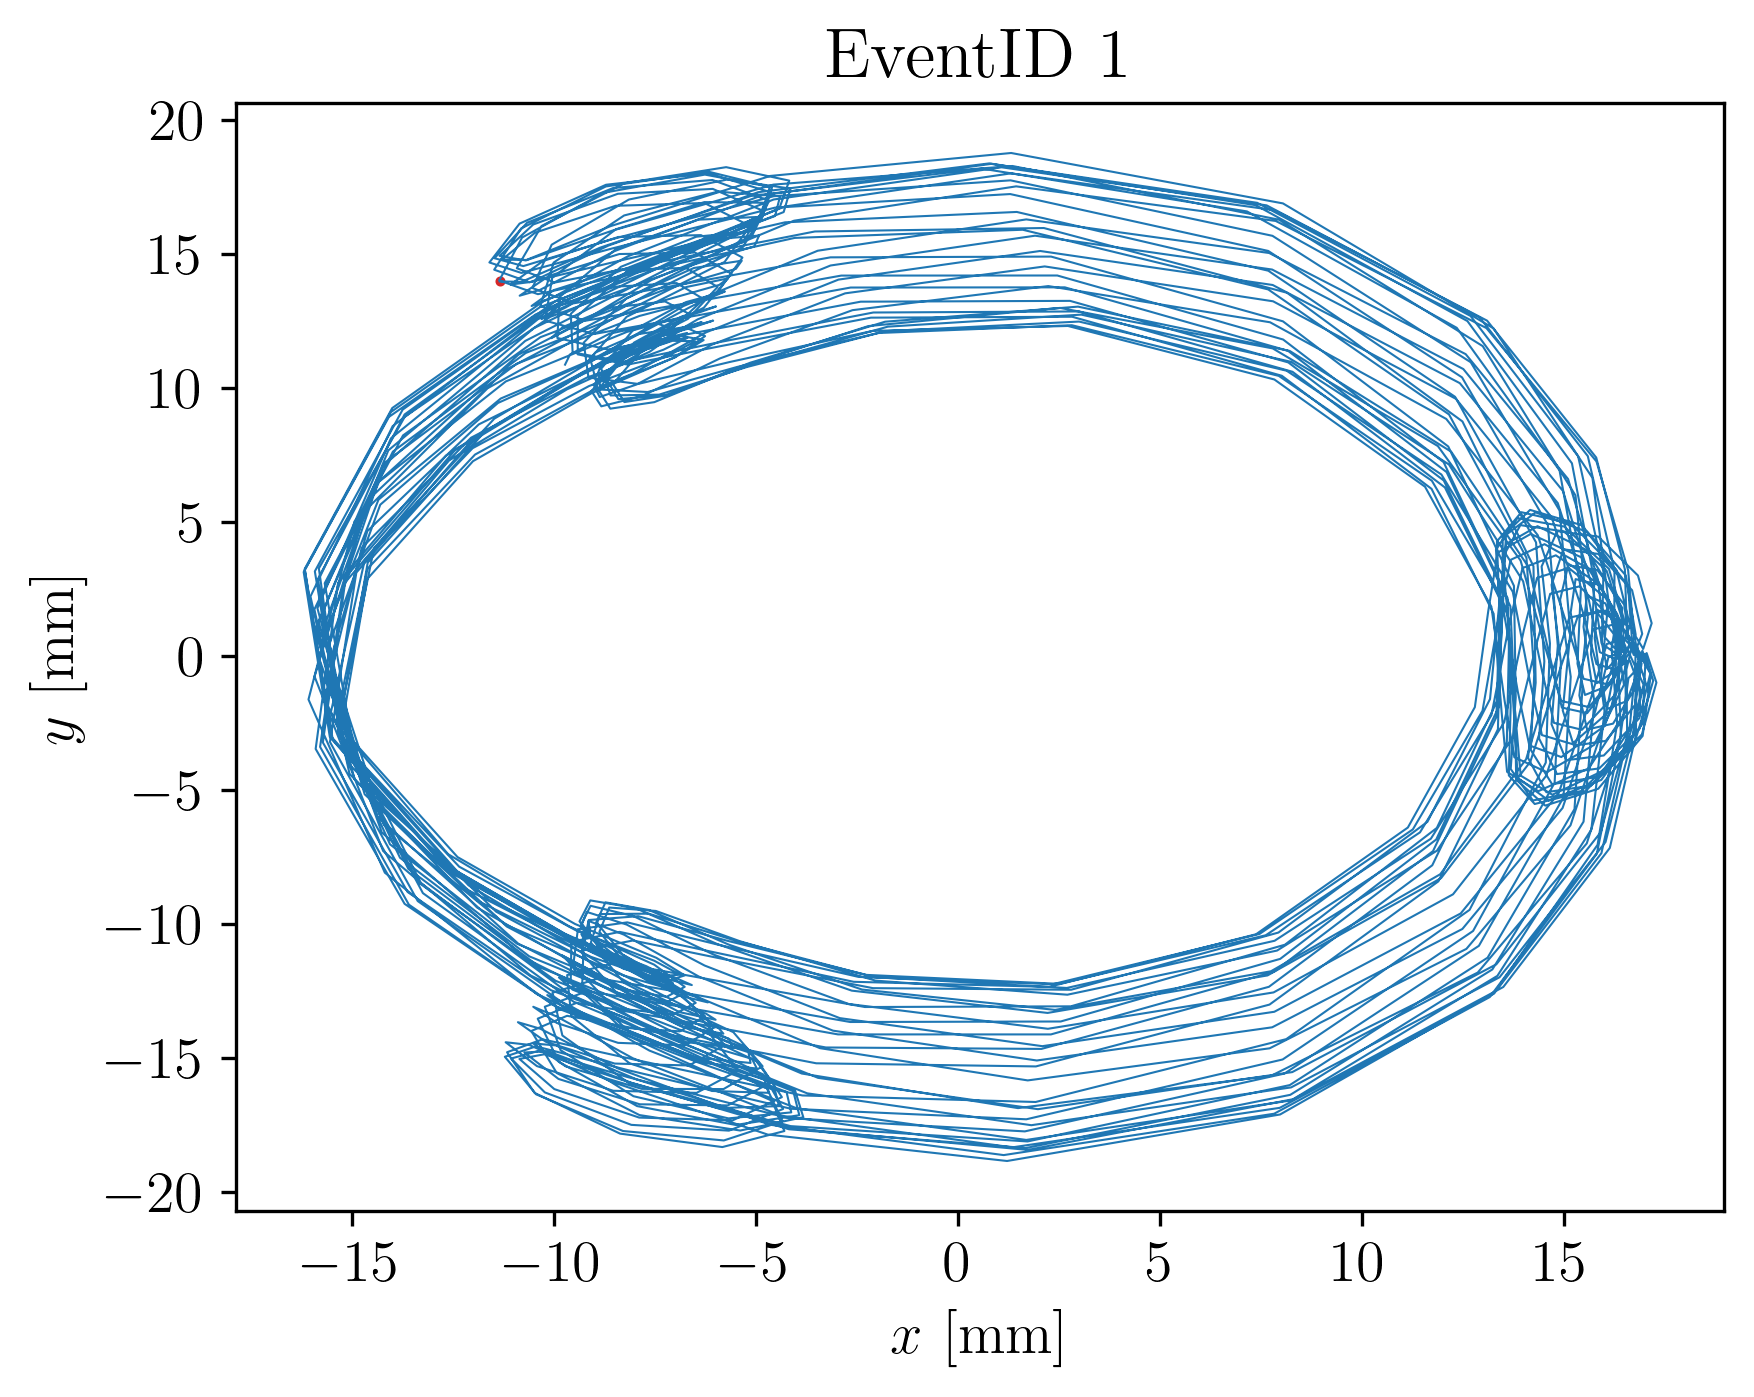

In [60]:
plt.figure()
plt.plot(data_beam[data_beam['EventID']==solID]['x'], data_beam[data_beam['EventID']==solID]['y'],lw=0.5)
plt.scatter(data_beam[data_beam['EventID']==solID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==solID][data_beam['z']==0]['y'],color='tab:red',s=2);
plt.title(f'EventID {int(solID)}')
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');

In [61]:
np.min(diffs)

np.float64(0.03774612562899749)

param X=-11.3752
param Y=14.0458
param Xp=0.00336102
param Yp=-0.00629481

beam gaussian particle=mu+ nEvents=10000 \
beamZ=0.0 beamX=$X beamY=$Y beamXp=$Xp beamYp=$Yp \ 
sigmaX=0.05 sigmaY=0.05 sigmaXp=0.005 sigmaYp=0.005 \ 
meanMomentum=$p sigmaP=0.0 meanT=0.0 sigmaT=0.0


param X=-11.3477
param Y=13.9798
param Xp=-0.00123932
param Yp=-0.00637463

beam gaussian particle=mu+ nEvents=10 \
beamZ=0.0 beamX=$X beamY=$Y beamXp=$Xp beamYp=$Yp \ 
sigmaX=0.0 sigmaY=0.0 sigmaXp=0.0 sigmaYp=0.0 \ 
meanMomentum=$p sigmaP=0.0 meanT=0.0 sigmaT=0.0

### for all 30 periods

In [ ]:
data_beam = readDetData('zntuple.txt')

In [ ]:
period_len = 4200
IDs = np.unique(data_beam['EventID'])
diffs = []
for ID in IDs:
    x0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['x'].values[0]
    xf = data_beam[data_beam['EventID']==ID][data_beam['z']==period_len*30]['x'].values[0]
    y0 = data_beam[data_beam['EventID']==ID][data_beam['z']==0]['y'].values[0]
    yf = data_beam[data_beam['EventID']==ID][data_beam['z']==period_len*30]['y'].values[0]
    diff = np.sqrt((xf-x0)**2+(yf-y0)**2)
    diffs.append(diff)

In [ ]:
solID = int(IDs[np.where(diffs==np.min(diffs))][0])
print(solID)

In [ ]:
init = data_beam[data_beam['EventID']==solID][data_beam['z']==0];
print(f"x : {init['x'].values}")
print(f"y : {init['y'].values}")
print(f"xp : {init['xp'].values}")
print(f"yp : {init['yp'].values}")

In [ ]:
plt.figure()
plt.plot(data_beam[data_beam['EventID']==solID]['x'], data_beam[data_beam['EventID']==solID]['y'],lw=0.5)
plt.scatter(data_beam[data_beam['EventID']==solID][data_beam['z']==0]['x'], data_beam[data_beam['EventID']==solID][data_beam['z']==0]['y'],color='tab:red',s=2);
plt.title(f'EventID {int(solID)}')
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');